In [ ]:
# Task 4: Responsible AI & Model Interpretation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Evaluate model
y_pred = rf_model.predict(X_test)

print("Task 4 model trained successfully! ✅")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Task 4 model trained successfully! ✅
Accuracy: 0.956140350877193

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Top 15 Important Features:


,Feature,Importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


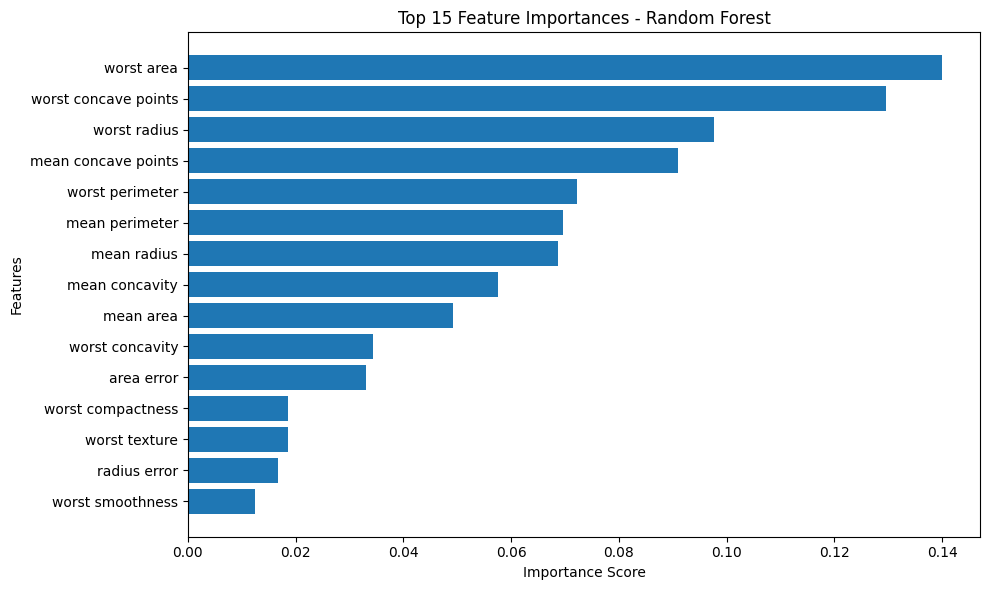

In [ ]:
# Feature Importance Analysis

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
print("Top 15 Important Features:")
display(feature_importance.head(15))

# Plot top 15 features
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"].head(15)[::-1],
    feature_importance["Importance"].head(15)[::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

SHAP values calculated successfully! ✅


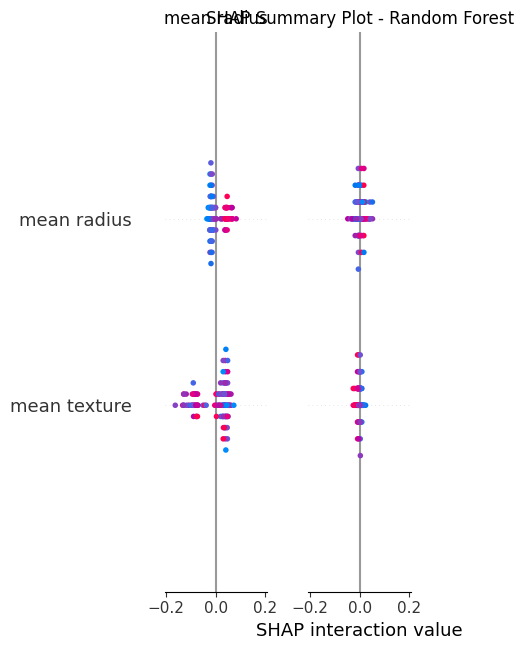

In [ ]:
# SHAP Explainability Analysis

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully! ✅")

# Handle SHAP output format
if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        X_test,
        show=False
    )
else:
    shap.summary_plot(
        shap_values,
        X_test,
        show=False
    )

plt.title("SHAP Summary Plot - Random Forest")
plt.tight_layout()
plt.show()

Predicted Class: malignant
Prediction Probability: [1. 0.]


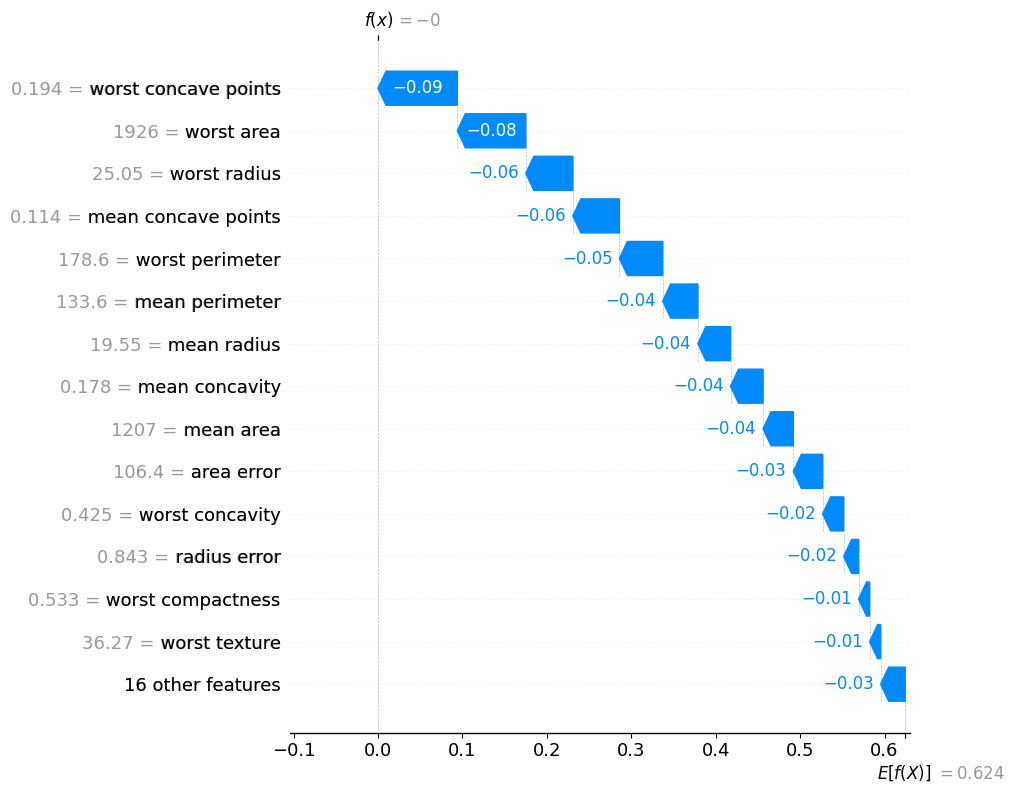

In [ ]:
# SHAP Local Explanation

# Select one sample from test data
sample_index = 0

sample = X_test.iloc[[sample_index]]

# Display sample prediction
prediction = rf_model.predict(sample)[0]
probability = rf_model.predict_proba(sample)[0]

print("Predicted Class:", data.target_names[prediction])
print("Prediction Probability:", probability)

# Create SHAP waterfall plot
sample_shap_values = explainer(sample)

# Handle binary classification output
if len(sample_shap_values.shape) == 3:
    sample_shap_values = sample_shap_values[:, :, 1]

shap.plots.waterfall(
    sample_shap_values[0],
    max_display=15,
    show=True
)

In [ ]:
# Responsible AI: Fairness and Bias Analysis

print("FAIRNESS AND BIAS ANALYSIS")
print("=" * 40)

# Check available dataset features
print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])

# Sensitive demographic attributes check
sensitive_attributes = [
    "age",
    "gender",
    "sex",
    "race",
    "ethnicity"
]

available_attributes = [
    col for col in X.columns
    if col.lower() in sensitive_attributes
]

print("\nSensitive attributes found:", available_attributes)

if len(available_attributes) == 0:
    print("\nLimitation:")
    print(
        "The dataset does not contain direct demographic "
        "attributes such as age, gender, race, or ethnicity."
    )
    print(
        "Therefore, group-wise fairness metrics cannot "
        "be reliably calculated for these attributes."
    )

print("\nPotential Bias Risks:")
print("1. Dataset may not represent all population groups.")
print("2. Model performance may vary across unseen groups.")
print("3. Clinical decisions should not rely only on model predictions.")

print("\nRecommended Mitigation:")
print("1. Collect representative demographic data with proper consent.")
print("2. Evaluate performance separately across relevant groups.")
print("3. Monitor accuracy, recall, and false-negative rates.")
print("4. Use human clinical oversight for medical decisions.")

FAIRNESS AND BIAS ANALYSIS
Number of features: 30
Number of samples: 569

Sensitive attributes found: []

Limitation:
The dataset does not contain direct demographic attributes such as age, gender, race, or ethnicity.
Therefore, group-wise fairness metrics cannot be reliably calculated for these attributes.

Potential Bias Risks:
1. Dataset may not represent all population groups.
2. Model performance may vary across unseen groups.
3. Clinical decisions should not rely only on model predictions.

Recommended Mitigation:
1. Collect representative demographic data with proper consent.
2. Evaluate performance separately across relevant groups.
3. Monitor accuracy, recall, and false-negative rates.
4. Use human clinical oversight for medical decisions.


In [ ]:
# Responsible AI - Final Analysis

responsible_ai_report = """
# Responsible AI & Model Interpretation

## 1. Project Overview
This project uses a Random Forest classifier
for Breast Cancer Classification.

## 2. Model Performance
The model achieved an accuracy of approximately 95.61%
on the test dataset.

## 3. Explainability
Feature importance analysis was used to identify
the features that influence model predictions.
SHAP was used for:4
- Global feature interpretation
- Local prediction explanation
- Understanding feature contributions

## 4. Fairness and Bias Analysis
The dataset does not contain direct demographic
attributes such as age, gender, race, or ethnicity.

Therefore, group-wise fairness metrics cannot be
reliably calculated for these attributes.

The absence of demographic attributes does not
guarantee that the model is free from bias.

## 5. Potential Bias Risks
- The dataset may not represent all population groups.
- Model performance may vary across different groups.
- Dataset imbalance or limited representation may
  affect model reliability.

## 6. Mitigation Recommendations
1. Use diverse and representative datasets.
2. Collect demographic information only when
   appropriate, ethically justified, and permitted.
3. Evaluate recall, precision, and false-negative
   rates across relevant groups.
4. Monitor model performance after deployment.
5. Keep human clinical oversight for medical decisions.
6. Avoid using model predictions as the sole basis
   for diagnosis or treatment.

## 7. Conclusion
The analysis demonstrates the use of feature importance
and SHAP for model interpretation.

Fairness evaluation is limited by the absence of
sensitive demographic attributes in the dataset.
Further validation with representative data is required
before real-world clinical use.
"""

print(responsible_ai_report)


# Responsible AI & Model Interpretation

## 1. Project Overview
This project uses a Random Forest classifier
for Breast Cancer Classification.

## 2. Model Performance
The model achieved an accuracy of approximately 95.61%
on the test dataset.

## 3. Explainability
Feature importance analysis was used to identify
the features that influence model predictions.

SHAP was used for:
- Global feature interpretation
- Local prediction explanation
- Understanding feature contributions

## 4. Fairness and Bias Analysis
The dataset does not contain direct demographic
attributes such as age, gender, race, or ethnicity.

Therefore, group-wise fairness metrics cannot be
reliably calculated for these attributes.

The absence of demographic attributes does not
guarantee that the model is free from bias.

## 5. Potential Bias Risks
- The dataset may not represent all population groups.
- Model performance may vary across different groups.
- Dataset imbalance or limited representation may
  affect mo